<a href="https://colab.research.google.com/github/derryllyp/aapl-moving-average-strategy/blob/main/ma_crossover_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
price=150
print(price)

150


In [ ]:
ticker="AAPL"
shares=20
print(ticker)
print(shares)


AAPL
20


In [ ]:
buy_price=150
sell_price=165
profit=buy_price-sell_price
pct_return=profit/buy_price
print(profit)
print(pct_return)

-15
-0.1


In [ ]:
buy_price=150
sell_price=165
profit=sell_price-buy_price
pct_return=profit/buy_price
print(profit)
print(pct_return)

15
0.1


In [ ]:
prices=[150,152,149,155,160]
print(prices)
print(prices[0])
print(prices[-1])

[150, 152, 149, 155, 160]
150
160


In [ ]:
for price in prices:
  print(price)
for price in prices:
  print(price*2)

150
152
149
155
160
300
304
298
310
320


In [ ]:
for i  in range(1, len(prices)):
  change=prices[i]-prices[i-1]
  print(change)

2
-3
6
5


In [ ]:
prices=[150,152,149,155,160]
for i in range(1, len(prices)):
  change=prices[i]-prices[i-1]
  print(change)


2
-3
6
5


In [ ]:
import pandas as pd
data={"day":[1,2,3,4,5,], "price":[150,152,149,155,160]}
df=pd.DataFrame(data)
print(df)

   day  price
0    1    150
1    2    152
2    3    149
3    4    155
4    5    160


In [ ]:
print(df["price"].Diff())

AttributeError: 'Series' object has no attribute 'Diff'

In [ ]:
print(df["prices"].diff())

In [ ]:
print(df["price"].diff())

In [ ]:
!pip install yfinance
import yfinance as yf

stock=yf.download("AAPL", start="2015-01-01", end="2026-01-01")
print(stock.head())

/tmp/ipykernel_18160/3292102125.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download("AAPL", start="2015-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192614  24.659516  23.754477  24.648451  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513277  23.772175  23.152589  23.575235  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759083  24.816616  24.053197  24.170477  237458000


In [ ]:
print(stock.shape)

(2766, 5)


In [ ]:
close=stock["Close"]
print(close.head())

Ticker           AAPL
Date                 
2015-01-02  24.192614
2015-01-05  23.511063
2015-01-06  23.513277
2015-01-07  23.842981
2015-01-08  24.759083


In [ ]:
!pip install yfinance
import yfinance as yf
stock=yf.download("AAPL",start="2015-01-01",end="2026-01-01")
close=stock["Close"]
close=close.squeeze()
print(type(close))
print(close.head())

/tmp/ipykernel_18160/3916302417.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock=yf.download("AAPL",start="2015-01-01",end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
Date
2015-01-02    24.192614
2015-01-05    23.511063
2015-01-06    23.513277
2015-01-07    23.842981
2015-01-08    24.759083
Name: AAPL, dtype: float64


In [ ]:
short_ma=close.rolling(window=50).mean()
long_ma=close.rolling(window=200).mean()

In [ ]:
print(short_ma.tail())
print(long_ma.tail())

Date
2025-12-24    270.452087
2025-12-26    270.937215
2025-12-29    271.467224
2025-12-30    271.887131
2025-12-31    272.084244
Name: AAPL, dtype: float64
Date
2025-12-24    229.774617
2025-12-26    230.059884
2025-12-29    230.383256
2025-12-30    230.684284
2025-12-31    230.976687
Name: AAPL, dtype: float64


In [ ]:
signal=short_ma>long_ma
print(signal.tail())

Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: bool


In [ ]:
previous_signal=signal.shift(1)
print(signal.tail())
print(previous_signal.tail())


Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: bool
Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: object


In [ ]:
changed=signal!=previous_signal
crossovers=signal[changed]
print(crossovers)

Date
2015-01-02    False
2016-08-30     True
2018-12-21    False
2019-05-06     True
2022-06-03    False
2022-09-26     True
2022-10-07    False
2023-03-22     True
2024-03-14    False
2024-06-13     True
2025-04-07    False
2025-09-15     True
Name: AAPL, dtype: bool


In [ ]:
short_ma=close.rolling(window=50).mean()
long_ma=close.rolling(window=200).mean()

In [ ]:
print(short_ma.tail())
print(long_ma.tail())

Date
2025-12-24    270.452087
2025-12-26    270.937215
2025-12-29    271.467224
2025-12-30    271.887131
2025-12-31    272.084244
Name: AAPL, dtype: float64
Date
2025-12-24    229.774617
2025-12-26    230.059884
2025-12-29    230.383256
2025-12-30    230.684284
2025-12-31    230.976687
Name: AAPL, dtype: float64


In [ ]:
signal=short_ma>long_ma
print(signal.tail())

Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: bool


In [ ]:
previous_signal=signal.shift(1)
print(signal.tail())
print(previous_signal.tail())

Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: bool
Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: object


In [ ]:
changed=signal!=previous_signal
crossovers=signal[changed]
print(crossovers)

Date
2015-01-02    False
2016-08-30     True
2018-12-21    False
2019-05-06     True
2022-06-03    False
2022-09-26     True
2022-10-07    False
2023-03-22     True
2024-03-14    False
2024-06-13     True
2025-04-07    False
2025-09-15     True
Name: AAPL, dtype: bool


In [ ]:
daily_returns=close.pct_change()
print(daily_returns.tail())

Date
2025-12-24    0.005324
2025-12-26   -0.001497
2025-12-29    0.001317
2025-12-30   -0.002484
2025-12-31   -0.004468
Name: AAPL, dtype: float64


In [ ]:
position=signal.shift(1)
position=position.fillna(False)
print(position.tail())

Date
2025-12-24    True
2025-12-26    True
2025-12-29    True
2025-12-30    True
2025-12-31    True
Name: AAPL, dtype: bool


/tmp/ipykernel_18160/186929729.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  position=position.fillna(False)


In [ ]:
strategy_returns=daily_returns*position
print(strategy_returns.tail())

Date
2025-12-24    0.005324
2025-12-26   -0.001497
2025-12-29    0.001317
2025-12-30   -0.002484
2025-12-31   -0.004468
Name: AAPL, dtype: float64


In [ ]:
cumulative_strategy=(1+strategy_returns).cumprod()-1
cumulative_hold=(1+daily_returns).cumprod()-1
print(cumulative_strategy.tail())
print(cumulative_hold.tail())

Date
2025-12-24    3.260892
2025-12-26    3.254512
2025-12-29    3.260114
2025-12-30    3.249532
2025-12-31    3.230547
Name: AAPL, dtype: float64
Date
2025-12-24    10.296928
2025-12-26    10.280012
2025-12-29    10.294867
2025-12-30    10.266810
2025-12-31    10.216475
Name: AAPL, dtype: float64


In [ ]:
import numpy as np

sharpe_strategy=(strategy_returns.mean()/strategy_returns.std())*np.sqrt(252)
sharpe_hold=(daily_returns.mean()/daily_returns.std())*np.sqrt(252)

print(sharpe_strategy)
print(sharpe_hold)

0.6778727103512197
0.9081093740370996


In [ ]:
wealth_strategy=cumulative_strategy+1
wealth_hold=cumulative_hold+1

peak_strategy=wealth_strategy.cummax()
peak_hold=wealth_hold.cummax()

drawdown_strategy=(wealth_strategy-peak_strategy)/peak_strategy
drawdown_hold=(wealth_hold-peak_hold)/peak_hold

max_drawdown_strategy=drawdown_strategy.min()
max_drawdown_hold=drawdown_hold.min()

print(max_drawdown_strategy)
print(max_drawdown_hold)

-0.4561277852044297
-0.38515904474709917


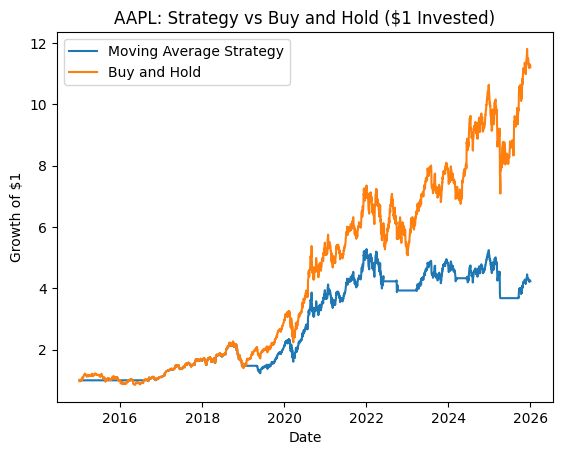

In [ ]:
import matplotlib.pyplot as plt

plt.plot(wealth_strategy, label="Moving Average Strategy")
plt.plot(wealth_hold, label="Buy and Hold")
plt.title("AAPL: Strategy vs Buy and Hold ($1 Invested)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.savefig("equity_curve.png")
plt.show()